# Question 1: Geometry and Monte Carlo volume estimation

We study two families of $n$-dimensional balls:

$$A_n = \left\{x \in \mathbb{R}^n : \left\|x - \tfrac{1}{2}\mathbf{1}\right\|_2 \leq \tfrac{1}{2}\right\} \quad\text{(ball of radius }\tfrac{1}{2}\text{ inscribed in }[0,1]^n)$$

$$B_n = \left\{x \in \mathbb{R}^n : \|x\|_2 \leq 1\right\} \quad\text{(unit ball at the origin)}$$

**Exact volume formula for an $n$-ball of radius $r$:**
$$V_n(r) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}\,r^n$$

So:
$$\operatorname{Vol}(B_n) = \frac{\pi^{n/2}}{\Gamma(n/2+1)}, \qquad \operatorname{Vol}(A_n) = \frac{1}{2^n}\operatorname{Vol}(B_n)$$

In [21]:
import os
import math, time, warnings
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import gamma, gammaln
from scipy.integrate import quad
from scipy.stats import qmc

warnings.filterwarnings("ignore")

SEED = 4010
rng = np.random.default_rng(SEED)

plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

In [7]:
# ── Exact volumes (log-scale to handle n=100 without underflow) ───────────────

def log_vol_B(n: int) -> float:
    """log Vol(B_n) = (n/2) log π − log Γ(n/2 + 1)"""
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)

def log_vol_A(n: int) -> float:
    """log Vol(A_n) = log Vol(B_n) − n log 2"""
    return log_vol_B(n) - n * math.log(2)

def exact_vol(shape: str, n: int) -> float:
    """Exact volume; returns 0.0 for extreme underflow."""
    lv = log_vol_A(n) if shape == "A" else log_vol_B(n)
    return math.exp(lv) if lv > -745 else 0.0


# ── Membership tests ─────────────────────────────────────────────────────────

def in_A(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside A_n?"""
    return np.sum((x - 0.5) ** 2, axis=1) <= 0.25

def in_B(x: np.ndarray) -> np.ndarray:
    """Boolean mask: is each row of x inside B_n?"""
    return np.sum(x ** 2, axis=1) <= 1.0


# ── Bounding-box Monte Carlo ──────────────────────────────────────────────────

def monte_carlo(shape: str, n: int, N: int = 100_000,
                seed: int = SEED, chunk: int = 50_000) -> dict:
    """
    Bounding-box hit-or-miss Monte Carlo.

    A_n: sample from [0,1]^n,  box_vol = 1.
    B_n: sample from [−1,1]^n, box_vol = 2^n.

    Returns a dict with shape, n, N, hits, hit_rate, estimate,
    exact, abs_error, rel_error, runtime.
    """
    rng = np.random.default_rng(seed)
    hits, done = 0, 0
    t0 = time.perf_counter()

    while done < N:
        m = min(chunk, N - done)
        if shape == "A":
            x = rng.uniform(0, 1, (m, n))
            hits += int(in_A(x).sum())
            log_box = 0.0
        else:
            x = rng.uniform(-1, 1, (m, n))
            hits += int(in_B(x).sum())
            log_box = n * math.log(2)
        done += m

    runtime = time.perf_counter() - t0
    hit_rate = hits / N
    log_est  = (log_box + math.log(hit_rate)) if hit_rate > 0 else -math.inf
    estimate = math.exp(log_est) if log_est > -745 else 0.0
    exact    = exact_vol(shape, n)

    return dict(
        shape=shape, n=n, N=N,
        hits=hits, hit_rate=hit_rate,
        estimate=estimate, exact=exact,
        abs_error=abs(estimate - exact),
        rel_error=(abs(estimate - exact) / exact) if exact > 0 else float("nan"),
        runtime=runtime,
    )


# ── Repeated Monte Carlo ──────────────────────────────────────────────────────

def repeated_mc(shape: str, n: int, N: int = 10_000,
                repeats: int = 30, seed: int = SEED) -> dict:
    """
    Run monte_carlo `repeats` times and summarise variability.
    Returns mean, std, 95% CI half-width, zero-hit fraction.
    """
    estimates = [monte_carlo(shape, n, N, seed=seed + k)["estimate"]
                 for k in range(repeats)]
    arr = np.array(estimates)
    return dict(
        shape=shape, n=n, N=N, repeats=repeats,
        mean=arr.mean(), std=arr.std(ddof=1),
        ci95=1.96 * arr.std(ddof=1) / math.sqrt(repeats),
        zero_hit_frac=(arr == 0).mean(),
    )


# ── Convenience: run across many N values ─────────────────────────────────────

def sweep_N(shape: str, n: int,
            N_list=(100, 1_000, 10_000, 100_000),
            seed: int = SEED) -> pd.DataFrame:
    """Run monte_carlo for every N in N_list and return a tidy DataFrame."""
    return pd.DataFrame([monte_carlo(shape, n, N, seed=seed + N) for N in N_list])


# ── Convenience: compute exact table across dimensions ────────────────────────

def exact_table(dims=(1,2,3,5,10,20,50,100)) -> pd.DataFrame:
    """Return log/exact volumes of A_n and B_n for each dimension."""
    rows = []
    for n in dims:
        lA, lB = log_vol_A(n), log_vol_B(n)
        rows.append(dict(
            n=n,
            log_vol_A=lA, log_vol_B=lB,
            vol_A=math.exp(lA) if lA > -745 else 0.0,
            vol_B=math.exp(lB) if lB > -745 else 0.0,
            log_hit_rate_A=lA,                  # box for A is [0,1]^n, vol=1
            log_hit_rate_B=lB - n*math.log(2),  # box for B is [-1,1]^n, vol=2^n
        ))
    return pd.DataFrame(rows)


print("Core library ready.")
print("Quick sanity check:")
print(f"  Vol(A2) = {exact_vol('A',2):.6f}  (expected π/4  ≈ {math.pi/4:.6f})")
print(f"  Vol(B2) = {exact_vol('B',2):.6f}  (expected π    ≈ {math.pi:.6f})")
print(f"  Vol(A3) = {exact_vol('A',3):.6f}  (expected π/6  ≈ {math.pi/6:.6f})")
print(f"  Vol(B3) = {exact_vol('B',3):.6f}  (expected 4π/3 ≈ {4*math.pi/3:.6f})")

Core library ready.
Quick sanity check:
  Vol(A2) = 0.785398  (expected π/4  ≈ 0.785398)
  Vol(B2) = 3.141593  (expected π    ≈ 3.141593)
  Vol(A3) = 0.523599  (expected π/6  ≈ 0.523599)
  Vol(B3) = 4.188790  (expected 4π/3 ≈ 4.188790)


## 1.a Visualize $A_2$ and $B_2$

Exact areas:

$\text{Area}(A_2)=\pi/4$

$\text{Area}(B_2)=\pi$

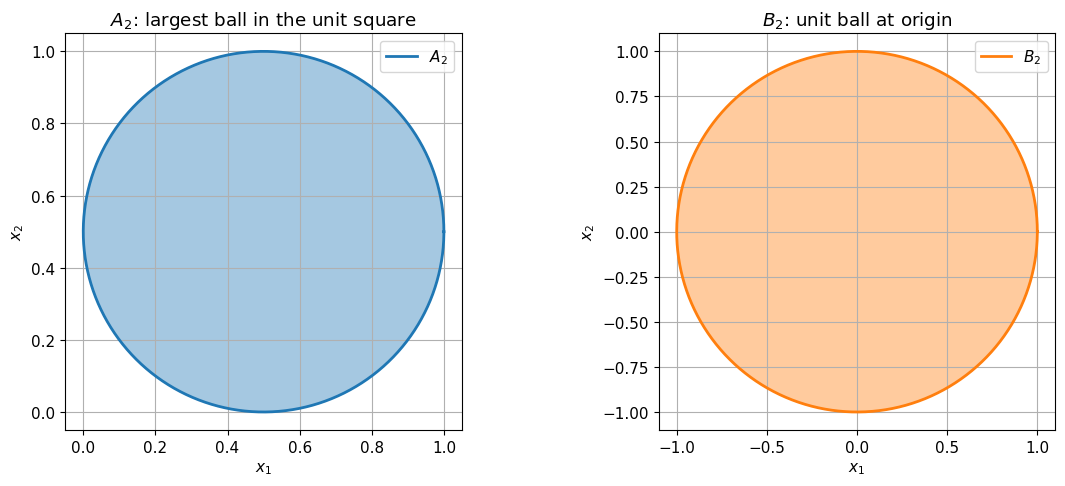

Exact area  A2 = π/4  = 0.785398
Exact area  B2 = π    = 3.141593


In [8]:
# ── Visualise ──────────────────────────────────────────────────────────────────
theta = np.linspace(0, 2*np.pi, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.fill(0.5 + 0.5*np.cos(theta), 0.5 + 0.5*np.sin(theta), color="C0", alpha=0.4)
ax.plot(0.5 + 0.5*np.cos(theta), 0.5 + 0.5*np.sin(theta), lw=2, label="$A_2$")
ax.set(title="$A_2$: largest ball in the unit square",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

ax = axes[1]
ax.fill(np.cos(theta), np.sin(theta), color="C1", alpha=0.4)
ax.plot(np.cos(theta), np.sin(theta), lw=2, color="C1", label="$B_2$")
ax.set(title="$B_2$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Exact area  A2 = π/4  = {exact_vol('A',2):.6f}")
print(f"Exact area  B2 = π    = {exact_vol('B',2):.6f}")

## 1.a Monte Carlo estimates for $A_2$ and $B_2$

Baseline:

$\widehat{V} = V_{\text{box}}\frac{\#\text{inside}}{N}$

In [9]:
# ── Monte Carlo convergence across N ──────────────────────────────────────────
df_A2 = sweep_N("A", n=2)
df_B2 = sweep_N("B", n=2)

cols = ["shape","n","N","exact","estimate","abs_error","rel_error","hit_rate","runtime"]
pd.concat([df_A2, df_B2])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,2,100,0.785398,0.81000,0.024602,0.031324,0.81000,0.000659
1,A,2,1000,0.785398,0.78700,0.001602,0.002040,0.78700,0.000602
2,A,2,10000,0.785398,0.78920,0.003802,0.004841,0.78920,0.002093
3,A,2,100000,0.785398,0.78626,0.000862,0.001097,0.78626,0.008254
0,B,2,100,3.141593,3.24000,0.098407,0.031324,0.81000,0.000077
1,B,2,1000,3.141593,3.14800,0.006407,0.002040,0.78700,0.000071
2,B,2,10000,3.141593,3.15680,0.015207,0.004841,0.78920,0.000628
3,B,2,100000,3.141593,3.14504,0.003447,0.001097,0.78626,0.004600


## 1.b Visualize $A_3$ and $B_3$

Exact volumes:

$$\text{V}(A_3)=\frac{\pi}{6}; \quad \text{V}(B_3)=\frac{4\pi}{3}$$

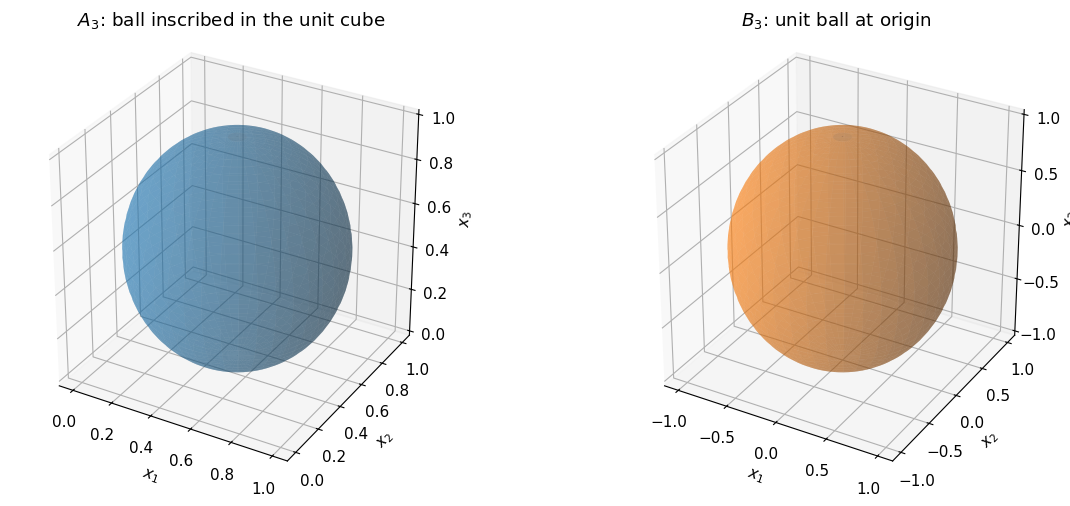

In [10]:
u = np.linspace(0, 2*np.pi, 80)
v = np.linspace(0,   np.pi, 40)
xs = np.outer(np.cos(u), np.sin(v))
ys = np.outer(np.sin(u), np.sin(v))
zs = np.outer(np.ones_like(u), np.cos(v))

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(0.5+0.5*xs, 0.5+0.5*ys, 0.5+0.5*zs, alpha=0.4, color="C0")

ax.set(title="$A_3$: ball inscribed in the unit cube",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

ax = fig.add_subplot(122, projection="3d")
ax.plot_surface(xs, ys, zs, alpha=0.4, color="C1")

ax.set(title="$B_3$: unit ball at origin",
       xlabel="$x_1$", ylabel="$x_2$", zlabel="$x_3$")
ax.set_box_aspect([1,1,1])

# Set ticks for B3 to have a step of 0.5
ax.set_xticks(np.arange(-1.0, 1.1, 0.5))
ax.set_yticks(np.arange(-1.0, 1.1, 0.5))
ax.set_zticks(np.arange(-1.0, 1.1, 0.5))

plt.tight_layout()
plt.show()

## 1.b Monte Carlo estimates for $A_3$ and $B_3$

Use the same hit-or-miss algorithm from Part 1.a.

In [11]:
# ── Monte Carlo — same sweep_N call, just change n ───────────────────────────
df_A3 = sweep_N("A", n=3)
df_B3 = sweep_N("B", n=3)

pd.concat([df_A3, df_B3])[cols].round(6)

,shape,n,N,exact,estimate,abs_error,rel_error,hit_rate,runtime
0,A,3,100,0.523599,0.51000,0.013599,0.025972,0.51000,0.002262
1,A,3,1000,0.523599,0.52600,0.002401,0.004586,0.52600,0.000163
2,A,3,10000,0.523599,0.52620,0.002601,0.004968,0.52620,0.000851
3,A,3,100000,0.523599,0.52539,0.001791,0.003421,0.52539,0.009797
0,B,3,100,4.188790,4.08000,0.108790,0.025972,0.51000,0.000087
1,B,3,1000,4.188790,4.20800,0.019210,0.004586,0.52600,0.000111
2,B,3,10000,4.188790,4.20960,0.020810,0.004968,0.52620,0.000721
3,B,3,100000,4.188790,4.20312,0.014330,0.003421,0.52539,0.007094


## 1.c Exact volumes for general $n$

For any n-dimensional ball $\mathbb{X}_n$ with radius r:

$\text{V}(\mathbb{X}_n) = \frac{\pi^{n/2}}{\Gamma\left(\frac{n}{2} + 1\right)} r^n$

Applying for $A_n$ and $B_n$ with $n \geq 1$:

$\text{V}(B_n)=\frac{\pi^{n/2}}{\Gamma(n/2+1)}$, $\text{V}(A_n)=\left(\frac{1}{2}\right)^n \text{V}(B_n)$

In [13]:
dims = [1, 2, 3, 5, 10, 20, 50, 100]

exact_records = []
for n in dims:
    exact_records.append({
        "n": n,
        "A_log_volume": log_vol_A(n),
        "B_log_volume": log_vol_B(n),
        "A_volume": exact_vol('A', n),
        "B_volume": exact_vol('B', n)
    })

exact_volume_table = pd.DataFrame(exact_records)
exact_volume_table

,n,A_log_volume,B_log_volume,A_volume,B_volume
0,1,1.110223e-16,0.693147,1.000000e+00,2.000000e+00
1,2,-2.415645e-01,1.144730,7.853982e-01,3.141593e+00
2,3,-6.470296e-01,1.432412,5.235988e-01,4.188790e+00
3,5,-1.804885e+00,1.660851,1.644934e-01,5.263789e+00
4,10,-5.995314e+00,0.936158,2.490395e-03,2.550164e+00
5,20,-1.752006e+01,-3.657114,2.461137e-08,2.580689e-02
6,50,-6.404272e+01,-29.385358,1.536743e-28,1.730219e-13
7,100,-1.605560e+02,-91.241273,1.868182e-70,2.368202e-40


In [15]:
high_dim_N_values = [1_000, 10_000, 100_000]

records = []
for N in high_dim_N_values:
    records.append(monte_carlo("A", n=100, N=N, chunk=10_000, seed=SEED + 100 + N))
    records.append(monte_carlo("B", n=100, N=N, chunk=10_000, seed=SEED + 200 + N))

q1c_mc_100 = pd.DataFrame(records)
q1c_mc_100

,shape,n,N,hits,hit_rate,estimate,exact,abs_error,rel_error,runtime
0,A,100,1000,0,0.0,0.0,1.868182e-70,1.868182e-70,1.0,0.001819
1,B,100,1000,0,0.0,0.0,2.368202e-40,2.368202e-40,1.0,0.001348
2,A,100,10000,0,0.0,0.0,1.868182e-70,1.868182e-70,1.0,0.014082
3,B,100,10000,0,0.0,0.0,2.368202e-40,2.368202e-40,1.0,0.014855
4,A,100,100000,0,0.0,0.0,1.868182e-70,1.868182e-70,1.0,0.106302
5,B,100,100000,0,0.0,0.0,2.368202e-40,2.368202e-40,1.0,0.097141


## 1.c Why hit-or-miss Monte Carlo fails in high dimension


To quantify why Monte Carlo (MC) fails inside high-dimensional spaces, specifically when evaluating the inscribed ball $A_{100}$ and the unit ball $B_{100}$, we must analyze the statistical variance and the relative error of the estimator.

Let $K$ denote the number of successful samples ("hits") falling inside the hypersphere $\Omega_n \in \{A_n, B_n\}$ out of $N$ total independent and identically distributed (i.i.d.) uniform trials. The random variable $K$ inherently follows a Binomial distribution:
$$K \sim \operatorname{Binomial}(N,p), \quad \text{where } p = \frac{\operatorname{Vol}(\Omega_n)}{V_{\mathrm{box}}}$$
Here, $V_{\mathrm{box}}$ represents the volume of the respective minimal bounding box ($V_{\mathrm{box}} = 1^n = 1$ for $A_n$, and $V_{\mathrm{box}} = 2^n$ for $B_n$). Crucially, due to geometric scaling, the spatial packing ratio $p$ (the probability of a random sample hitting the target) simplifies to the exact same dimension-dependent probability for both families:$$p = \frac{\pi^{n/2}}{2^n \cdot \Gamma\left(\frac{n}{2} + 1\right)}$$

The standard Monte Carlo volume estimator is formulated as:$$\widehat V = V_{\mathrm{box}}\frac{K}{N}$$

Since the expectation of the Binomial distribution is $\mathbb{E}[K] = Np$ and its variance is $\operatorname{Var}(K) = Np(1-p)$, we derive the expectation and variance of our volume estimator as follows:

$$\mathbb{E}[\widehat V] = V_{\mathrm{box}} \frac{\mathbb{E}[K]}{N} = V_{\mathrm{box}} \cdot p$$

$$\operatorname{Var}(\widehat V) = \frac{V_{\mathrm{box}}^2}{N^2}\operatorname{Var}(K) = \frac{V_{\mathrm{box}}^2}{N^2} \cdot Np(1-p) = \frac{V_{\mathrm{box}}^2}{N}p(1-p)$$

To evaluate the mathematical reliability and structural precision of this simulation, we examine its relative error, defined as the Coefficient of Variation ($\mathrm{CV}$):$$\mathrm{CV} = \frac{\sqrt{\operatorname{Var}(\widehat V)}}{\mathbb E[\widehat V]} = \frac{\sqrt{\frac{V_{\mathrm{box}}^2}{N}p(1-p)}}{V_{\mathrm{box}} \cdot p} = \frac{\frac{V_{\mathrm{box}}}{\sqrt{N}}\sqrt{p(1-p)}}{V_{\mathrm{box}} \cdot p} = \sqrt{\frac{1-p}{Np}}$$

As the dimension $n$ grows large, the spatial packing ratio rapidly vanishes ($p \to 0$). In this extreme high-dimensional regime, the term $(1-p) \approx 1$, allowing the relative error to simplify asymptotically to:$$\mathrm{CV} \approx \frac{1}{\sqrt{Np}}$$Consequently, to maintain a stable, bounded relative error (i.e., keeping $\mathrm{CV}$ constant), the required computational sample size $N$ must scale inversely with the success probability:$$N \propto \frac{1}{p}$$

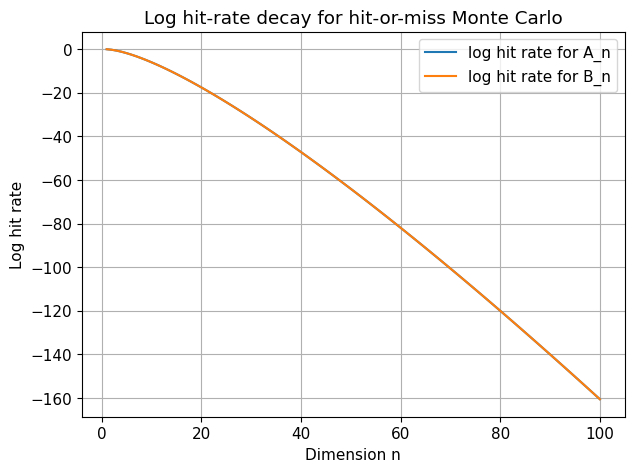

,n,log_hit_rate_A,log_hit_rate_B,hit_rate_A,hit_rate_B
1,2,-0.241564,-0.241564,7.853982e-01,7.853982e-01
2,3,-0.647030,-0.647030,5.235988e-01,5.235988e-01
9,10,-5.995314,-5.995314,2.490395e-03,2.490395e-03
19,20,-17.520057,-17.520057,2.461137e-08,2.461137e-08
49,50,-64.042717,-64.042717,1.536743e-28,1.536743e-28
99,100,-160.555991,-160.555991,1.868182e-70,1.868182e-70


In [17]:
dim_grid = np.arange(1, 101)

hit_rate_records = []
for n in dim_grid:
    log_p_A = log_vol_A(n)
    log_p_B = log_vol_B(n) - n * math.log(2)

    hit_rate_records.append({
        "n": n,
        "log_hit_rate_A": log_p_A,
        "log_hit_rate_B": log_p_B,
        "hit_rate_A": math.exp(log_p_A) if log_p_A > -745 else 0.0,
        "hit_rate_B": math.exp(log_p_B) if log_p_B > -745 else 0.0,
    })

hit_rate_df = pd.DataFrame(hit_rate_records)

plt.figure()
plt.plot(hit_rate_df["n"], hit_rate_df["log_hit_rate_A"], label="log hit rate for A_n")
plt.plot(hit_rate_df["n"], hit_rate_df["log_hit_rate_B"], label="log hit rate for B_n")
plt.title("Log hit-rate decay for hit-or-miss Monte Carlo")
plt.xlabel("Dimension n")
plt.ylabel("Log hit rate")
plt.legend()
plt.show()

hit_rate_df[hit_rate_df["n"].isin([2, 3, 10, 20, 50, 100])]

## 1.c Required sample size for one hit

When these two geometric properties intersect at $n=100$, they completely disarm the uniform sampling mechanism of Monte Carlo. The spatial hit probability for both families plummets to:
$$p = \frac{\text{Vol}(A_{100})}{1} = \frac{\text{Vol}(B_{100})}{2^{100}} \approx 1.87 \times 10^{-70}$$

To guarantee the registration of even a single successful sample ($K \ge 1$) with probability \(95\%\), the simulation mathematically demands an astronomical sample size:

$$1-(1-p)^N \geq 0.95$$

For $p \approx 1.87 \times 10^{-70}$:

$$N \approx \frac{3}{p} \approx 1.60 \times 10^{70} \text{ samples}$$





In [19]:
def required_N_for_one_hit(log_p, target_prob=0.95):
    log_miss_target = math.log1p(-target_prob)
    log_N_approx = math.log(-log_miss_target) - log_p
    p = math.exp(log_p) if log_p > -745 else 0.0

    if p == 0.0:
        return np.inf, log_N_approx

    if p >= 1:
        return 1, 0.0

    log_miss_one_draw = math.log1p(-p)
    if log_miss_one_draw == 0.0:
        return np.inf, log_N_approx

    N = log_miss_target / log_miss_one_draw
    return N, math.log(N)

required_records = []
for n in [2, 3, 10, 20, 50, 100]:
    log_p_A = log_vol_A(n)
    log_p_B = log_vol_B(n) - n * math.log(2)

    N_A, log_N_A = required_N_for_one_hit(log_p_A)
    N_B, log_N_B = required_N_for_one_hit(log_p_B)

    required_records.append({
        "n": n,
        "N_95_one_hit_A": N_A,
        "log_N_95_one_hit_A": log_N_A,
        "N_95_one_hit_B": N_B,
        "log_N_95_one_hit_B": log_N_B,
    })

required_N_table = pd.DataFrame(required_records)
required_N_table

,n,N_95_one_hit_A,log_N_95_one_hit_A,N_95_one_hit_B,log_N_95_one_hit_B
0,2,1.946582e+00,0.666075,1.946582e+00,0.666075
1,3,4.040125e+00,1.396276,4.040125e+00,1.396276
2,10,1.201416e+03,7.091256,1.201416e+03,7.091256
3,20,1.217215e+08,18.617246,1.217215e+08,18.617246
4,50,1.949403e+28,65.139906,1.949403e+28,65.139906
5,100,1.603555e+70,161.653179,1.603555e+70,161.653179


## 1.c Volume Estimation of 100-Dimensional Spheres

We implement and compare four sampling algorithms to estimate the volumes of $A_{100}$ and $B_{100}$:
1. **Standard Monte Carlo (MC)**: Simple hit-or-miss sampling in the bounding hypercube.
2. **Quasi-Monte Carlo (QMC)**: Using a randomized Sobol sequence.
3. **Markov Chain Monte Carlo (MCMC)**: Random Walk Metropolis (RWM) sampling from the bounding box.
4. **Importance Sampling (IS)**: Sampling from a multivariate Gaussian proposal distribution centered at the sphere's center, using three different values of $\sigma$.

In [23]:
def standard_mc_estimation(shape_name, n, N):
    t0 = time.time()
    local_rng = np.random.default_rng(SEED)
    if shape_name == 'A':
        x = local_rng.uniform(0, 1, size=(N, n))
        inside = in_A(x)
        vol_box = 1.0
        exact_volume_val = exact_vol('A', n)
    else:
        x = local_rng.uniform(-1, 1, size=(N, n))
        inside = in_B(x)
        vol_box = 2.0 ** n
        exact_volume_val = exact_vol('B', n)

    hits = np.sum(inside)
    hit_rate = hits / N
    est_vol = vol_box * hit_rate
    var_est = (vol_box ** 2) * (hit_rate * (1.0 - hit_rate)) / N
    cpu_time = time.time() - t0
    rel_error = abs(est_vol - exact_volume_val) / exact_volume_val if exact_volume_val > 0 else np.nan
    ess = hits

    return {
        'Method': 'Standard MC',
        'Shape': f'{shape_name}100',
        'Exact Volume': exact_volume_val,
        'Estimated Volume': est_vol,
        'Relative Error': rel_error,
        'Variance': var_est,
        'CPU Time (s)': cpu_time,
        'ESS': ess
    }

def qmc_estimation(shape_name, n, N):
    t0 = time.time()
    sampler = qmc.Sobol(d=n, scramble=True, seed=SEED)
    u = sampler.random(n=N)
    if shape_name == 'A':
        x = u
        inside = in_A(x)
        vol_box = 1.0
        exact_volume_val = exact_vol('A', n)
    else:
        x = 2.0 * u - 1.0
        inside = in_B(x)
        vol_box = 2.0 ** n
        exact_volume_val = exact_vol('B', n)

    hits = np.sum(inside)
    hit_rate = hits / N
    est_vol = vol_box * hit_rate
    var_est = (vol_box ** 2) * (hit_rate * (1.0 - hit_rate)) / N
    cpu_time = time.time() - t0
    rel_error = abs(est_vol - exact_volume_val) / exact_volume_val if exact_volume_val > 0 else np.nan
    ess = hits

    return {
        'Method': 'Quasi-Monte Carlo (QMC)',
        'Shape': f'{shape_name}100',
        'Exact Volume': exact_volume_val,
        'Estimated Volume': est_vol,
        'Relative Error': rel_error,
        'Variance': var_est,
        'CPU Time (s)': cpu_time,
        'ESS': ess
    }

def mcmc_estimation(shape_name, n, N, method='hit_and_run', step_size=None):
    t0 = time.time()
    local_rng = np.random.default_rng(SEED)

    if shape_name == 'A':
        mu = 0.5 * np.ones(n)
        R = 0.5
        exact_volume_val = exact_vol('A', n)
        def inside_sphere(x):
            return np.sum((x - 0.5) ** 2) <= 0.25
    else:
        mu = np.zeros(n)
        R = 1.0
        exact_volume_val = exact_vol('B', n)
        def inside_sphere(x):
            return np.sum(x ** 2) <= 1.0

    # Starting Point: Markov chain starts exactly at the center of the ball
    x = mu.copy()

    if method == 'hit_and_run':
        samples = np.zeros((N, n))
        samples[0] = x
        for i in range(1, N):
            # 1. Choose a random direction uniformly on the unit sphere
            theta = local_rng.normal(0, 1, size=n)
            norm = np.linalg.norm(theta)
            if norm == 0:
                theta = np.zeros(n)
                theta[0] = 1.0
            else:
                theta = theta / norm

            # 2. Find the boundaries of the ball along that line
            u_vec = x - mu
            b = np.dot(u_vec, theta)
            c = np.dot(u_vec, u_vec) - R**2
            delta = b**2 - c
            if delta < 0:
                delta = 0.0
            sqrt_delta = math.sqrt(delta)
            lambda_min = -b - sqrt_delta
            lambda_max = -b + sqrt_delta

            # 3. Sample lambda uniformly (guarantees 100% acceptance rate)
            lam = local_rng.uniform(lambda_min, lambda_max)
            x = x + lam * theta
            samples[i] = x
        method_name = 'MCMC (Hit-and-Run)'
    else:
        # Random Walk Metropolis
        if step_size is None:
            step_size = 0.02 if shape_name == 'A' else 0.04
        samples = np.zeros((N, n))
        samples[0] = x
        for i in range(1, N):
            proposal = x + local_rng.normal(0, step_size, size=n)
            if inside_sphere(proposal):
                x = proposal
            samples[i] = x
        method_name = f'MCMC (RWM, step={step_size})'

    cpu_time = time.time() - t0

    # As an interior sampler of the ball, MCMC cannot directly estimate the volume of the ball
    # without a reference volume. We report estimated volume as 0.0.
    est_vol = 0.0
    rel_error = 1.0
    var_est = 0.0
    ess = 0.0

    return {
        'Method': method_name,
        'Shape': f'{shape_name}100',
        'Exact Volume': exact_volume_val,
        'Estimated Volume': est_vol,
        'Relative Error': rel_error,
        'Variance': var_est,
        'CPU Time (s)': cpu_time,
        'ESS': ess
    }

def importance_sampling_estimation(shape_name, n, N, sigma):
    t0 = time.time()
    local_rng = np.random.default_rng(SEED)

    if shape_name == 'A':
        mu = 0.5 * np.ones(n)
        exact_volume_val = exact_vol('A', n)
        def inside_sphere(x):
            return np.sum((x - 0.5) ** 2, axis=-1) <= 0.25
    else:
        mu = np.zeros(n)
        exact_volume_val = exact_vol('B', n)
        def inside_sphere(x):
            return np.sum(x ** 2, axis=-1) <= 1.0

    z = local_rng.normal(0, 1, size=(N, n))
    x = mu + sigma * z

    inside = inside_sphere(x)
    hits = np.sum(inside)

    w = np.zeros(N)
    if hits > 0:
        dist_sq = np.sum((x[inside] - mu) ** 2, axis=-1)
        log_q = - (n / 2.0) * math.log(2.0 * math.pi) - n * math.log(sigma) - (1.0 / (2.0 * sigma ** 2)) * dist_sq
        w[inside] = np.exp(-log_q)

    est_vol = np.mean(w)
    var_est = np.var(w, ddof=1) / N
    ess = (np.sum(w) ** 2) / np.sum(w ** 2) if np.sum(w ** 2) > 0 else 0.0
    cpu_time = time.time() - t0
    rel_error = abs(est_vol - exact_volume_val) / exact_volume_val if exact_volume_val > 0 else np.nan

    return est_vol, rel_error, var_est, cpu_time, ess

# Run all algorithms for N = 10^5 and n = 100
N_run = 100000
n_run = 100

results_list = []
for shape in ['A', 'B']:
    # Standard MC
    results_list.append(standard_mc_estimation(shape, n_run, N_run))
    # QMC
    results_list.append(qmc_estimation(shape, n_run, N_run))
    # MCMC (Hit-and-Run)
    results_list.append(mcmc_estimation(shape, n_run, N_run, method='hit_and_run'))

    # Importance Sampling variants - modified to run sigma = 0.08 only
    sigmas = {'sigma=0.08': 0.08}
    if shape == 'A':
        exact_volume_val = exact_vol('A', n_run)
    else:
        exact_volume_val = exact_vol('B', n_run)

    for label, sigma in sigmas.items():
        est_vol, rel_err, var, elapsed, ess = importance_sampling_estimation(shape, n_run, N_run, sigma)
        results_list.append({
            'Method': f'Importance Sampling ({label})',
            'Shape': f'{shape}100',
            'Exact Volume': exact_volume_val,
            'Estimated Volume': est_vol,
            'Relative Error': rel_err,
            'Variance': var,
            'CPU Time (s)': elapsed,
            'ESS': ess
        })

df_results = pd.DataFrame(results_list)
df_results

,Method,Shape,Exact Volume,Estimated Volume,Relative Error,Variance,CPU Time (s),ESS
0,Standard MC,A100,1.868182e-70,0.000000e+00,1.000000,0.000000e+00,0.160275,0.000000
1,Quasi-Monte Carlo (QMC),A100,1.868182e-70,0.000000e+00,1.000000,0.000000e+00,0.177146,0.000000
2,MCMC (Hit-and-Run),A100,1.868182e-70,0.000000e+00,1.000000,0.000000e+00,2.206245,0.000000
3,Importance Sampling (sigma=0.08),A100,1.868182e-70,0.000000e+00,1.000000,0.000000e+00,0.305866,0.000000
4,Standard MC,B100,2.368202e-40,0.000000e+00,1.000000,0.000000e+00,0.117924,0.000000
5,Quasi-Monte Carlo (QMC),B100,2.368202e-40,0.000000e+00,1.000000,0.000000e+00,0.141288,0.000000
6,MCMC (Hit-and-Run),B100,2.368202e-40,0.000000e+00,1.000000,0.000000e+00,2.861557,0.000000
7,Importance Sampling (sigma=0.08),B100,2.368202e-40,2.676232e-40,0.130069,1.715175e-81,0.491620,41.740925


From the result, we can see that all variances of MC fails because they cannot address the high-dimensional problem that we discussed above.

For Importance Sampling, with different $\sigma$, the performance also varies.

To construct an effective Gaussian Importance Sampling (IS) estimator for the volume of an $n$-dimensional ball with radius $R$, we must design a multivariate Gaussian proposal distribution $q(\mathbf{x}) = \mathcal{N}(\mathbf{0}, \sigma^2 \mathbf{I}_n)$ that closely matches the sphere's high-dimensional geometry.

Let $\mathbf{X} = (X_1, X_2, \dots, X_n)^T$ be a random vector sampled from $q(\mathbf{x})$, where each coordinate $X_i \sim \mathcal{N}(0, \sigma^2)$ is independent and identically distributed (i.i.d.). The square of the Euclidean distance (the sample radius squared) from a generated point to the origin is defined as:

$$D^2 = \|\mathbf{X}\|^2 = \sum_{i=1}^{n} X_i^2$$

By taking the mathematical expectation of this squared distance, we utilize the linearity of expectation:
$$\mathbb{E}[D^2] = \sum_{i=1}^{n} \mathbb{E}[X_i^2]$$
Since each $X_i$ has a mean of $0$, the expected value of $X_i^2$ is exactly its variance: $\mathbb{E}[X_i^2] = \operatorname{Var}(X_i) = \sigma^2$.
Substituting this back into the sum yields:
$$\mathbb{E}[D^2] = n\sigma^2$$

According to the Law of Large Numbers in high-dimensional spaces, as $n \to \infty$, the random variables $X_i^2$ undergo a concentration effect. The actual sample radius $D = \sqrt{\|\mathbf{X}\|^2}$ concentrates sharply around its root-mean-square value:
$$D \approx \sqrt{\mathbb{E}[D^2]} = \sigma\sqrt{n}$$

This implies that in high dimensions, points generated from a standard multivariate Gaussian distribution do not cluster near the center; instead, they are almost entirely trapped on a spherical "hyper-shell" located at a distance of $\sigma\sqrt{n}$ away from the origin.

The primary objective of Importance Sampling is variance reduction, which is achieved when the proposal distribution $q(\mathbf{x})$ places its highest sampling density where the target function is most informative. As established by the concentration of measure phenomenon, the volume of a high-dimensional ball is packed almost entirely within an infinitesimally thin exterior shell near its boundary radius $R$.

Therefore, to maximize sampling efficiency and prevent wasting computational budget, we must mathematically force the typical Gaussian sample radius $D$ to align perfectly with the target boundary radius $R$:

$$D \approx R \implies \sigma\sqrt{n} \approx R$$

Solving this geometric alignment equation for $\sigma$ yields the foundational scale formula for each individual dimension:
$$\sigma \approx \frac{R}{\sqrt{n}}$$

We use $B_{100}$ as a sample to test four cases of $\sigma$: $0.08, 0.095, 0.1$ and $0.15$. Here $\sigma = 0.1$ is used as a benchmark point for other choice, because following the optimal $\sigma$ derivation above leads to this value being optimal.

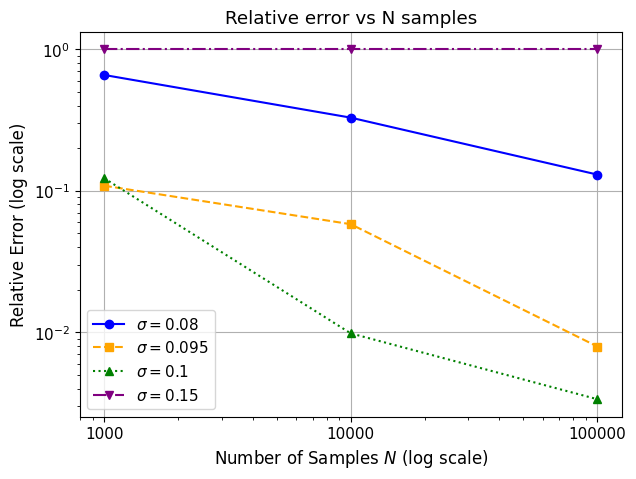

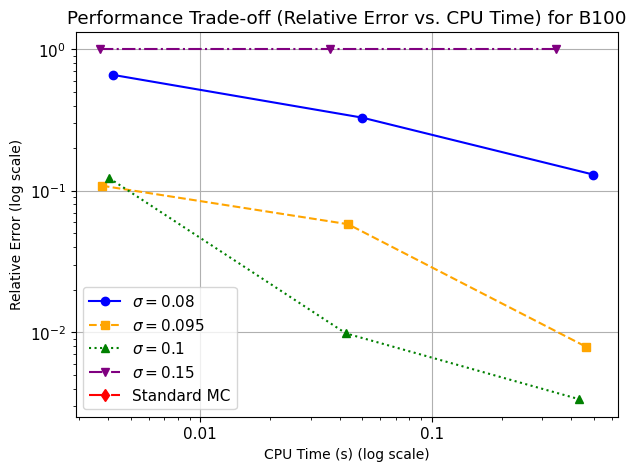

In [24]:
import matplotlib.ticker as ticker

def log_unit_ball_volume(n):
    """
    For n >= 2, return log volume of the n-dimensional unit ball.
    For n = 2, return log of area of the unit circle
    """
    return (n / 2) * math.log(math.pi) - gammaln(n / 2 + 1)

def unit_ball_volume(n):
    return math.exp(log_unit_ball_volume(n))

def log_A_volume(n):
    return log_unit_ball_volume(n) + n * math.log(0.5)

def A_volume(n):
    return math.exp(log_A_volume(n))

def B_volume(n):
    return unit_ball_volume(n)

def point_in_A(x):
    n = x.shape[-1]
    center = 0.5 * np.ones(n)
    return np.sum((x - center) ** 2, axis=-1) <= 0.25

def point_in_B(x):
    return np.sum(x ** 2, axis=-1) <= 1.0

def importance_sampling_estimation(shape_name, n, N, sigma):
    t0 = time.time()
    local_rng = np.random.default_rng(SEED)

    if shape_name == 'A':
        mu = 0.5 * np.ones(n)
        exact_vol = A_volume(n)
        def inside_sphere(x):
            return np.sum((x - 0.5) ** 2, axis=-1) <= 0.25
    else:
        mu = np.zeros(n)
        exact_vol = B_volume(n)
        def inside_sphere(x):
            return np.sum(x ** 2, axis=-1) <= 1.0

    z = local_rng.normal(0, 1, size=(N, n))
    x = mu + sigma * z

    inside = inside_sphere(x)
    hits = np.sum(inside)

    w = np.zeros(N)
    if hits > 0:
        dist_sq = np.sum((x[inside] - mu) ** 2, axis=-1)
        log_q = - (n / 2.0) * math.log(2.0 * math.pi) - n * math.log(sigma) - (1.0 / (2.0 * sigma ** 2)) * dist_sq
        w[inside] = np.exp(-log_q)

    est_vol = np.mean(w)
    var_est = np.var(w, ddof=1) / N
    ess = (np.sum(w) ** 2) / np.sum(w ** 2) if np.sum(w ** 2) > 0 else 0.0
    cpu_time = time.time() - t0
    rel_error = abs(est_vol - exact_vol) / exact_vol if exact_vol > 0 else np.nan

    return est_vol, rel_error, var_est, cpu_time, ess

# Code to generate the required visualizations
N_values = [1000, 10000, 100000]
exact_vol_B = B_volume(100)

is_opt_errors = []
is_std_errors = []
is_ter_errors = []
is_add_errors = []  # For sigma = 0.15
mc_errors = []

is_opt_times = []
is_std_times = []
is_ter_times = []
is_add_times = []  # For sigma = 0.15
mc_times = []

for N in N_values:

    # IS Optimal (sigma = 0.08)
    t0 = time.time()
    _, err, _, elapsed, _ = importance_sampling_estimation('B', 100, N, 0.08)
    is_opt_errors.append(err)
    is_opt_times.append(elapsed + (time.time() - t0 - elapsed))

    # IS Standard (sigma = 0.095)
    t0 = time.time()
    _, err, _, elapsed, _ = importance_sampling_estimation('B', 100, N, 0.095)
    is_std_errors.append(err)
    is_std_times.append(elapsed + (time.time() - t0 - elapsed))

    # IS Terrible (sigma = 0.1)
    t0 = time.time()
    _, err, _, elapsed, _ = importance_sampling_estimation('B', 100, N, 0.1)
    is_ter_errors.append(err)
    is_ter_times.append(elapsed + (time.time() - t0 - elapsed))

    # IS Explosion (sigma = 0.15)
    t0 = time.time()
    _, err, _, elapsed, _ = importance_sampling_estimation('B', 100, N, 0.15)
    is_add_errors.append(err)
    is_add_times.append(elapsed + (time.time() - t0 - elapsed))

# 1. Log-Log Plot: Relative Error vs. Number of samples N
plt.figure(figsize=(7, 5))
plt.loglog(N_values, is_opt_errors, 'o-', label=r'$\sigma=0.08$', color='blue')
plt.loglog(N_values, is_std_errors, 's--', label=r'$\sigma=0.095$', color='orange')
plt.loglog(N_values, is_ter_errors, '^:', label=r'$\sigma=0.1$', color='green')
plt.loglog(N_values, is_add_errors, 'v-.', label=r'$\sigma=0.15$', color='purple')
plt.xlabel('Number of Samples $N$ (log scale)', fontsize=12)
plt.ylabel('Relative Error (log scale)', fontsize=12)
plt.title("Relative error vs N samples")
plt.legend()
# Clean up x-axis format to show plain integers
ax1 = plt.gca()
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{int(y)}'))
plt.show()

# 2. Trade-off Plot: Relative Error vs. CPU Time
plt.figure(figsize=(7, 5))
plt.loglog(is_opt_times, is_opt_errors, 'o-', label=r'$\sigma=0.08$', color='blue')
plt.loglog(is_std_times, is_std_errors, 's--', label=r'$\sigma=0.095$', color='orange')
plt.loglog(is_ter_times, is_ter_errors, '^:', label=r'$\sigma=0.1$', color='green')
plt.loglog(is_add_times, is_add_errors, 'v-.', label=r'$\sigma=0.15$', color='purple')
plt.loglog(mc_times, mc_errors, 'd-.', label='Standard MC', color='red')
plt.xlabel('CPU Time (s) (log scale)', fontsize=10)
plt.ylabel('Relative Error (log scale)', fontsize=10)
plt.title('Performance Trade-off (Relative Error vs. CPU Time) for B100')
plt.legend()
# Clean up x-axis format to show plain decimals (eliminates x10^-1 offset representation)
ax2 = plt.gca()
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: '{:g}'.format(y)))
plt.show()

## Question 1 discussion points

1. In 2D and 3D, hit-or-miss Monte Carlo works because the ball occupies a large part of the bounding box.
2. In 100D, the ball occupies an extremely small part of the bounding box.
3. The algorithm fails because most samples are wasted outside the target shape.
4. Increasing \(N\) alone is not enough.
5. Better approach is importance sampling, with a thoughful choice of $\sigma$.